# Make the figures (editable)

Regenerates every figure from `figure_data/figure_data.pkl` using the figure library `code/figures.py`. **One cell per figure** — edit and re-run to tweak. The final cell saves everything to `figures/` (PNG + PDF).

**Where to change things:** colours + labels are in `code/figure_config.py` (`STIM_COLORS`, `MODELS`); fonts / sizes / dpi are in `code/figure_style.mplstyle`. Edit either, then re-run the setup cell.

## Setup

In [1]:
%matplotlib inline
import sys
from pathlib import Path
def _find(rel):
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / rel).exists():
            return c / rel
    raise FileNotFoundError(rel + " (run from inside the bundle)")
CODE = _find("code"); DATA = _find("figure_data"); OUT = DATA.parent / "figures"
sys.path.insert(0, str(CODE))
import matplotlib.pyplot as plt
import figures as F
plt.style.use(str(CODE / 'figure_style.mplstyle'))
D = F.load(DATA)
print('models:', D['model_types'])
print('seeds present:', {k: len(v) for k, v in D['seeds_present'].items()})

models: ['classif_rl', 'rl_only', 'classif_rl_readout_only']
seeds present: {'classif_rl': 30, 'rl_only': 30, 'classif_rl_readout_only': 30}


## Bar metrics
`F.bar_metric(D, metric, model_types=...)` is reusable — pick any metric and any subset of models (colours keyed by model).

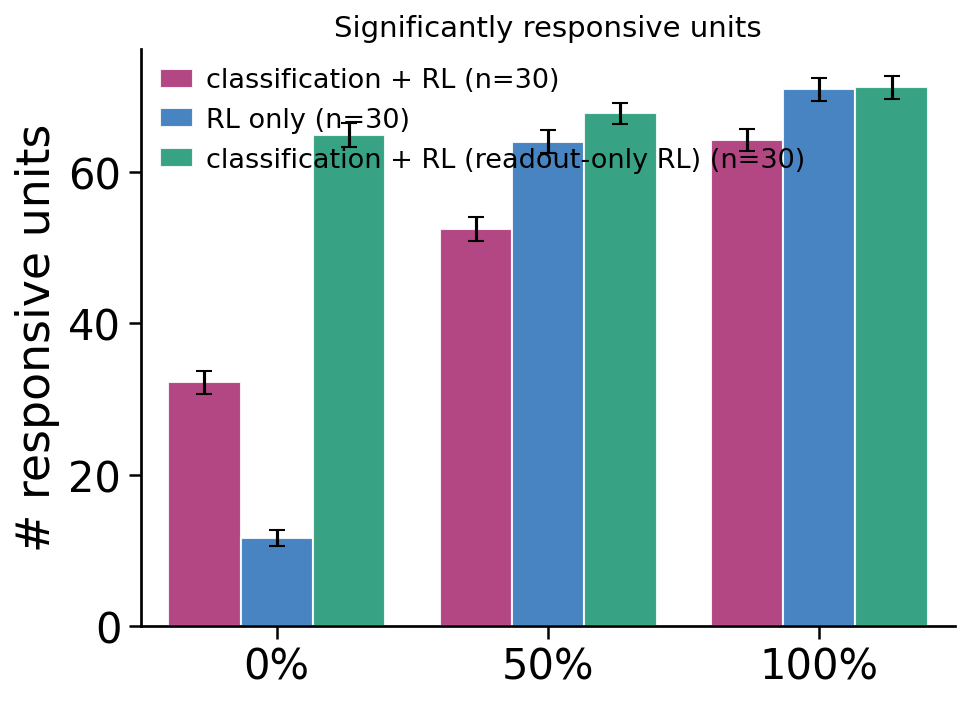

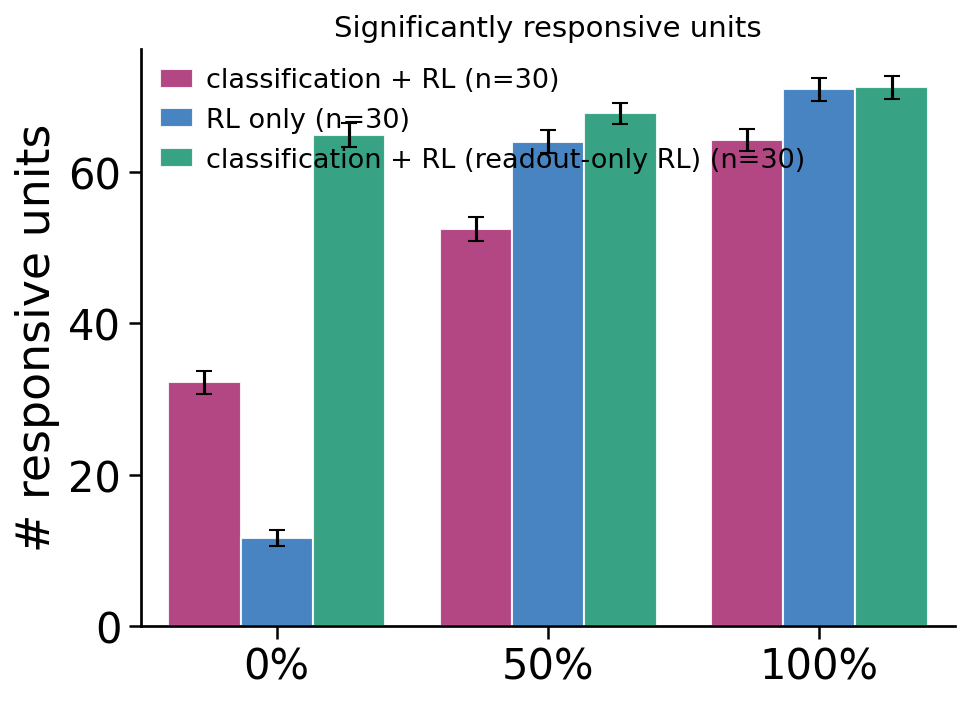

In [2]:
F.bar_metric(D, 'n_responsive', ylabel='# responsive units',
             title='Significantly responsive units')[0]

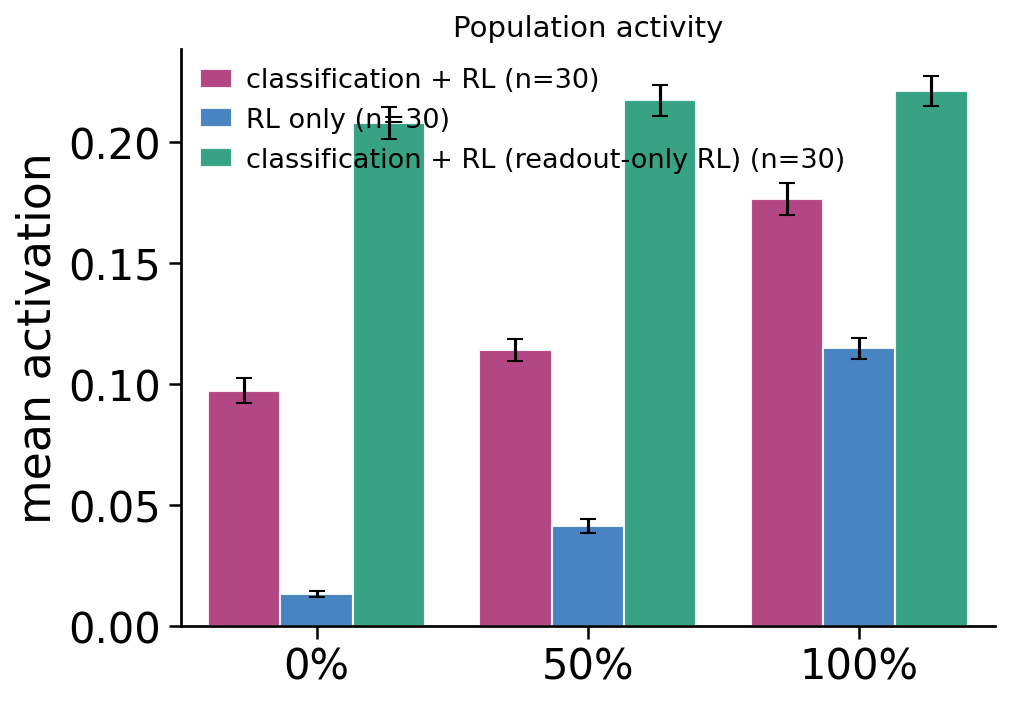

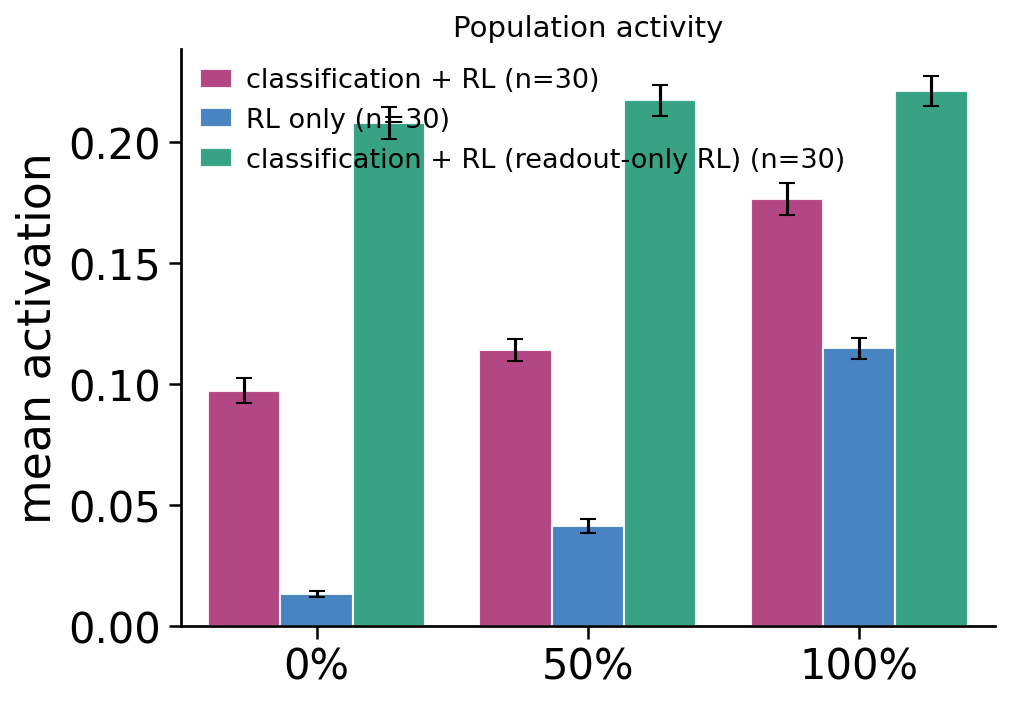

In [3]:
F.bar_metric(D, 'pop_activity', ylabel='mean activation',
             title='Population activity')[0]

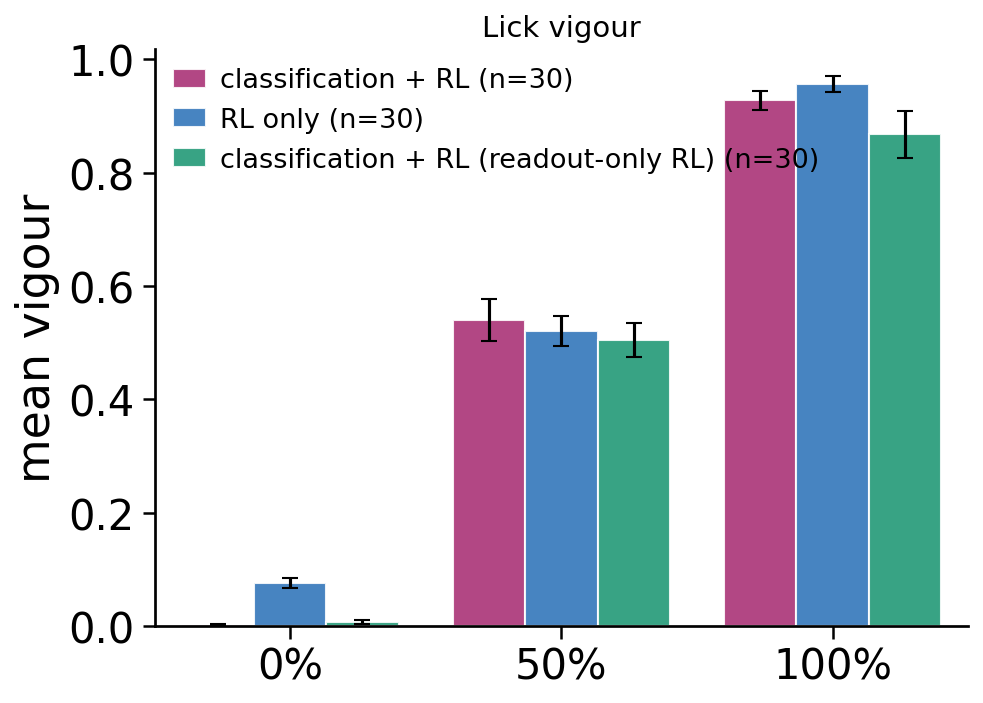

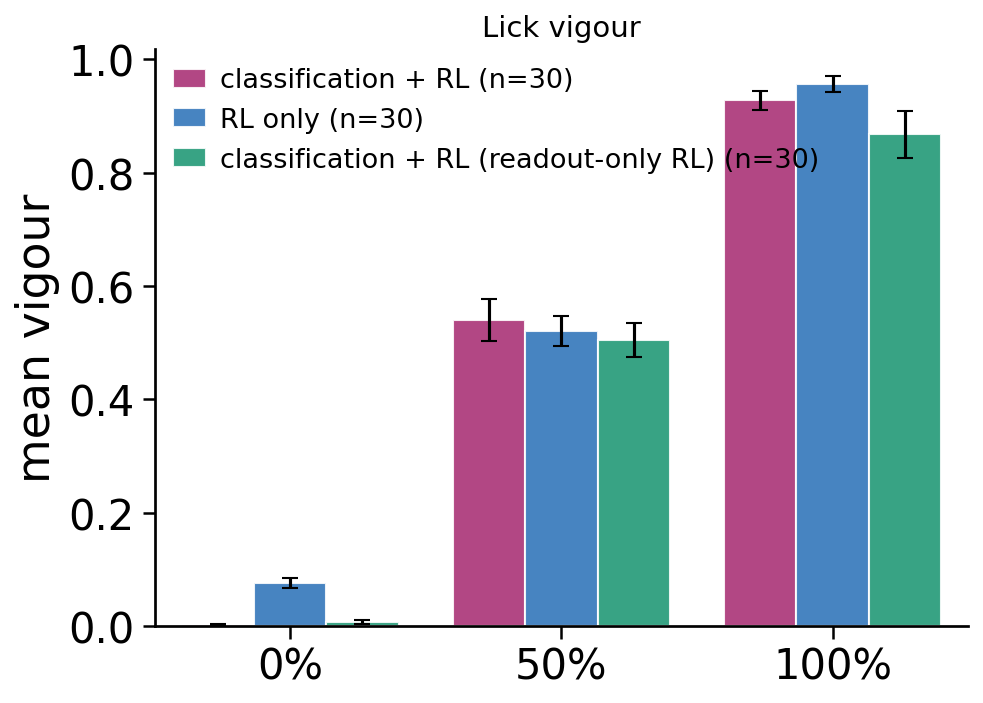

In [4]:
F.bar_metric(D, 'vigour', ylabel='mean vigour', title='Lick vigour')[0]

### Optionally annotate neuron count + percentage
Pass `annotate=True` (for `n_responsive` it prints the count and its % of all units above each bar).

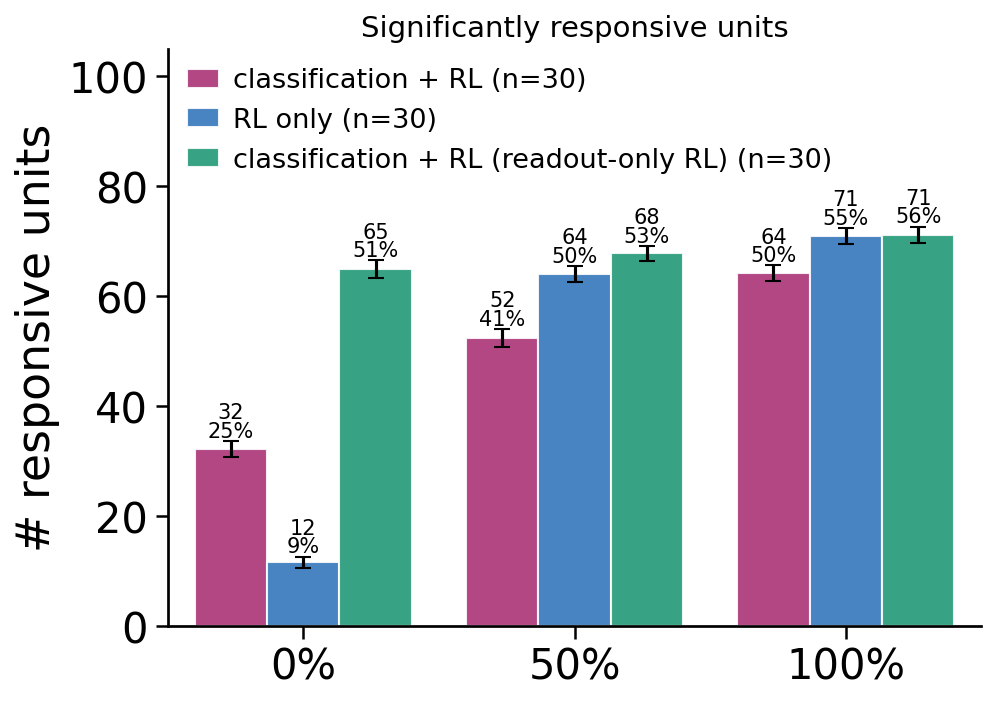

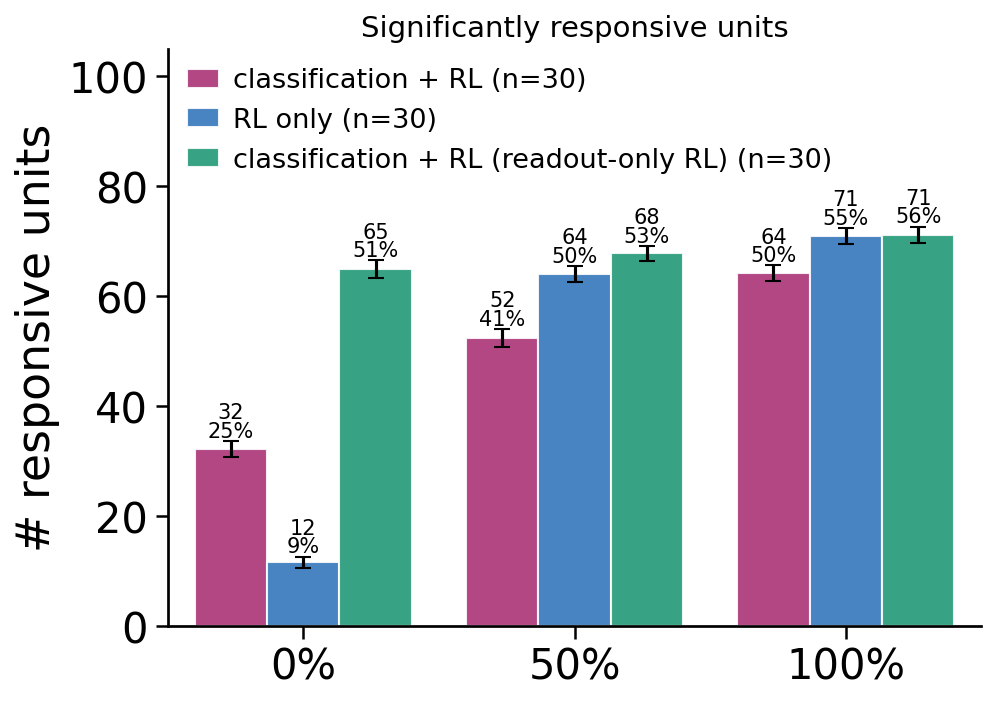

In [5]:
F.bar_metric(D, 'n_responsive', ylabel='# responsive units',
             title='Significantly responsive units',
             annotate=True, ylim=(0, 105))[0]

## Responder groups (exclusives + mixed) per model
`F.bar_responder_groups(D)` — # units in each responder group (the three exclusive types, three pairwise-mixed, and all-three), one coloured bar per model (mean ± SEM across seeds). Pass `fraction=True` for % of units.

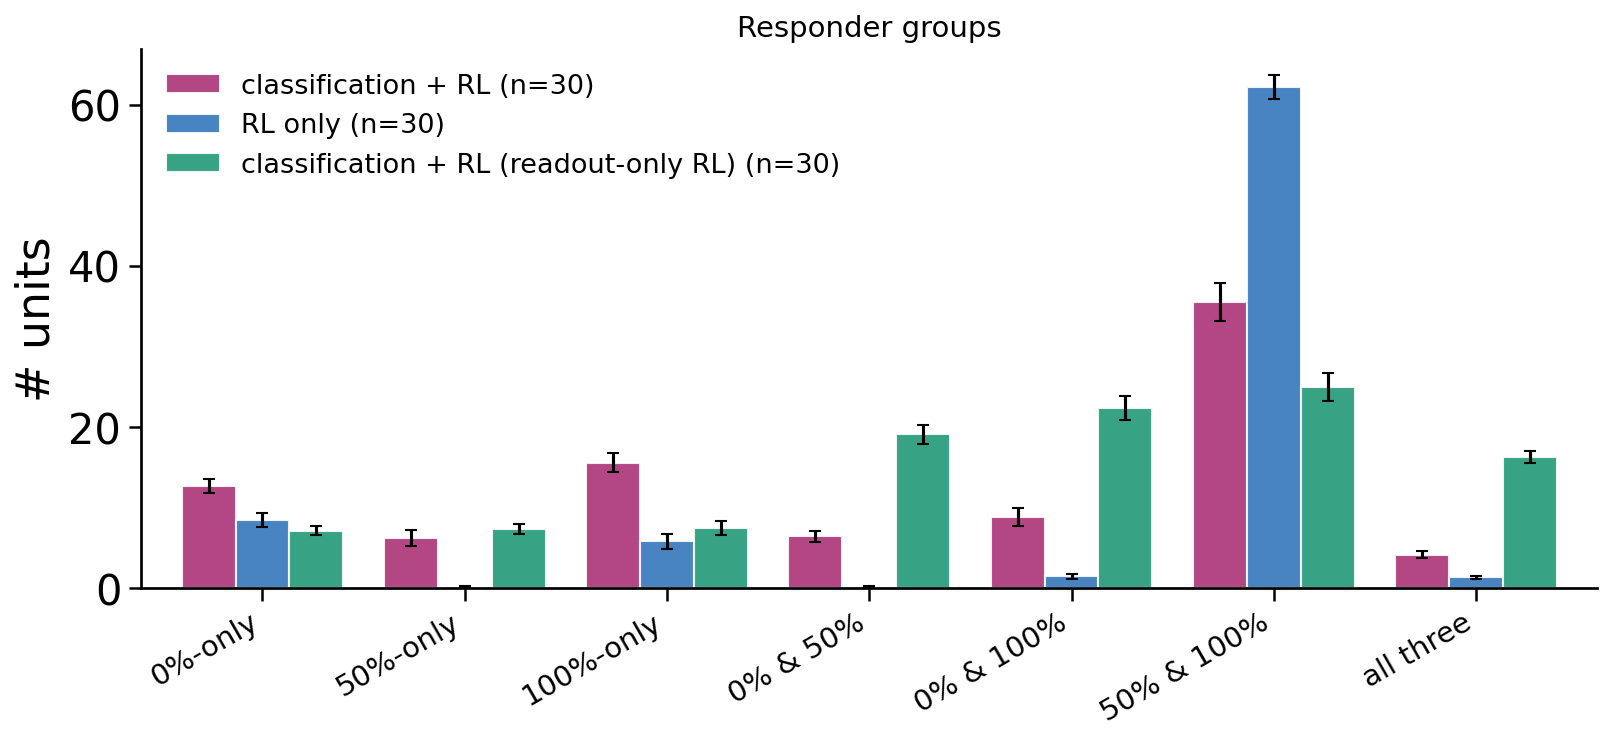

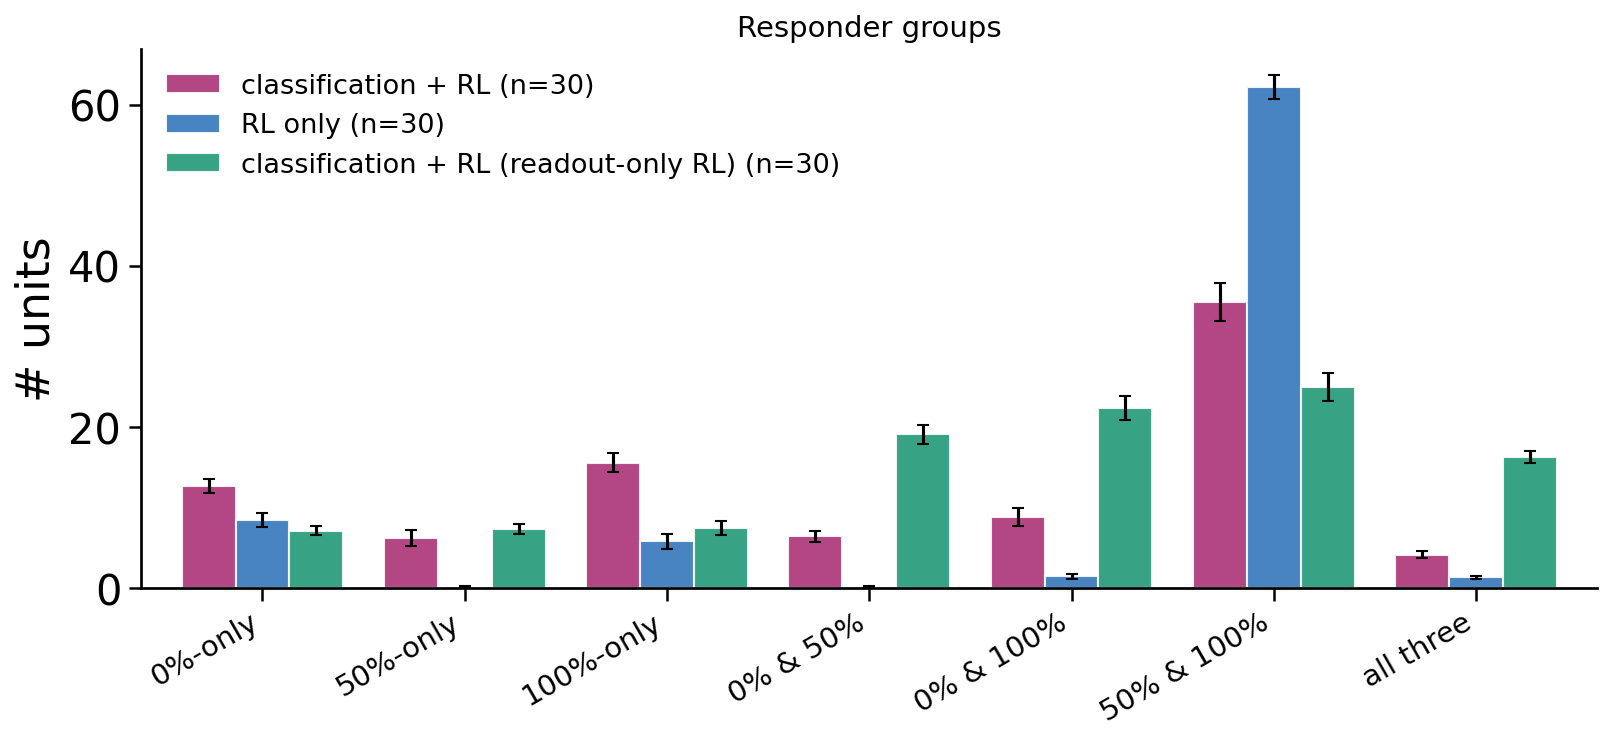

In [6]:
F.bar_responder_groups(D)[0]

## Per-seed heatmap
`F.heatmap_seed(D, model_type, seed)` — a single model+seed heatmap with the hidden units on the y-axis.

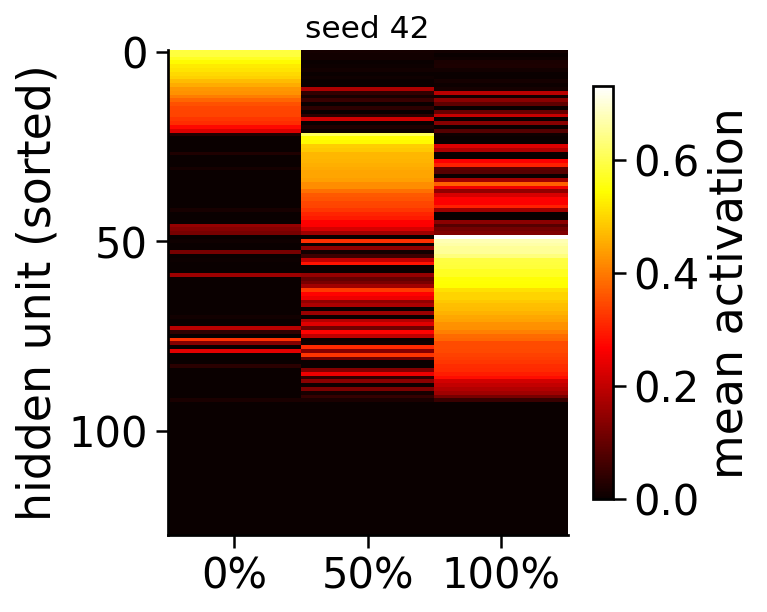

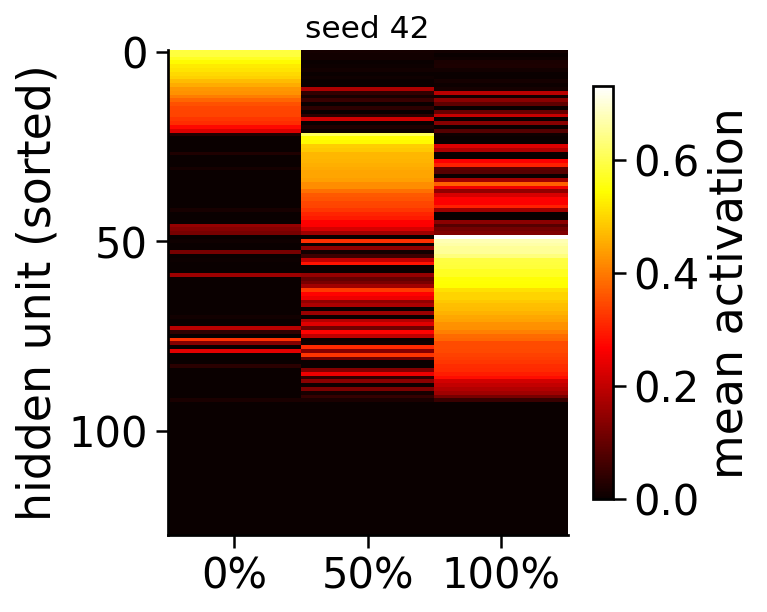

In [7]:
F.heatmap_seed(D, 'classif_rl', 42)[0]

## Per-seed heatmap montage (one model)
Pass a shared `vmax` (e.g. `F.tuning_vmax(D)`) to put all models on a **common colour scale** so their heatmaps are directly comparable — this is what `make_all` does by default.

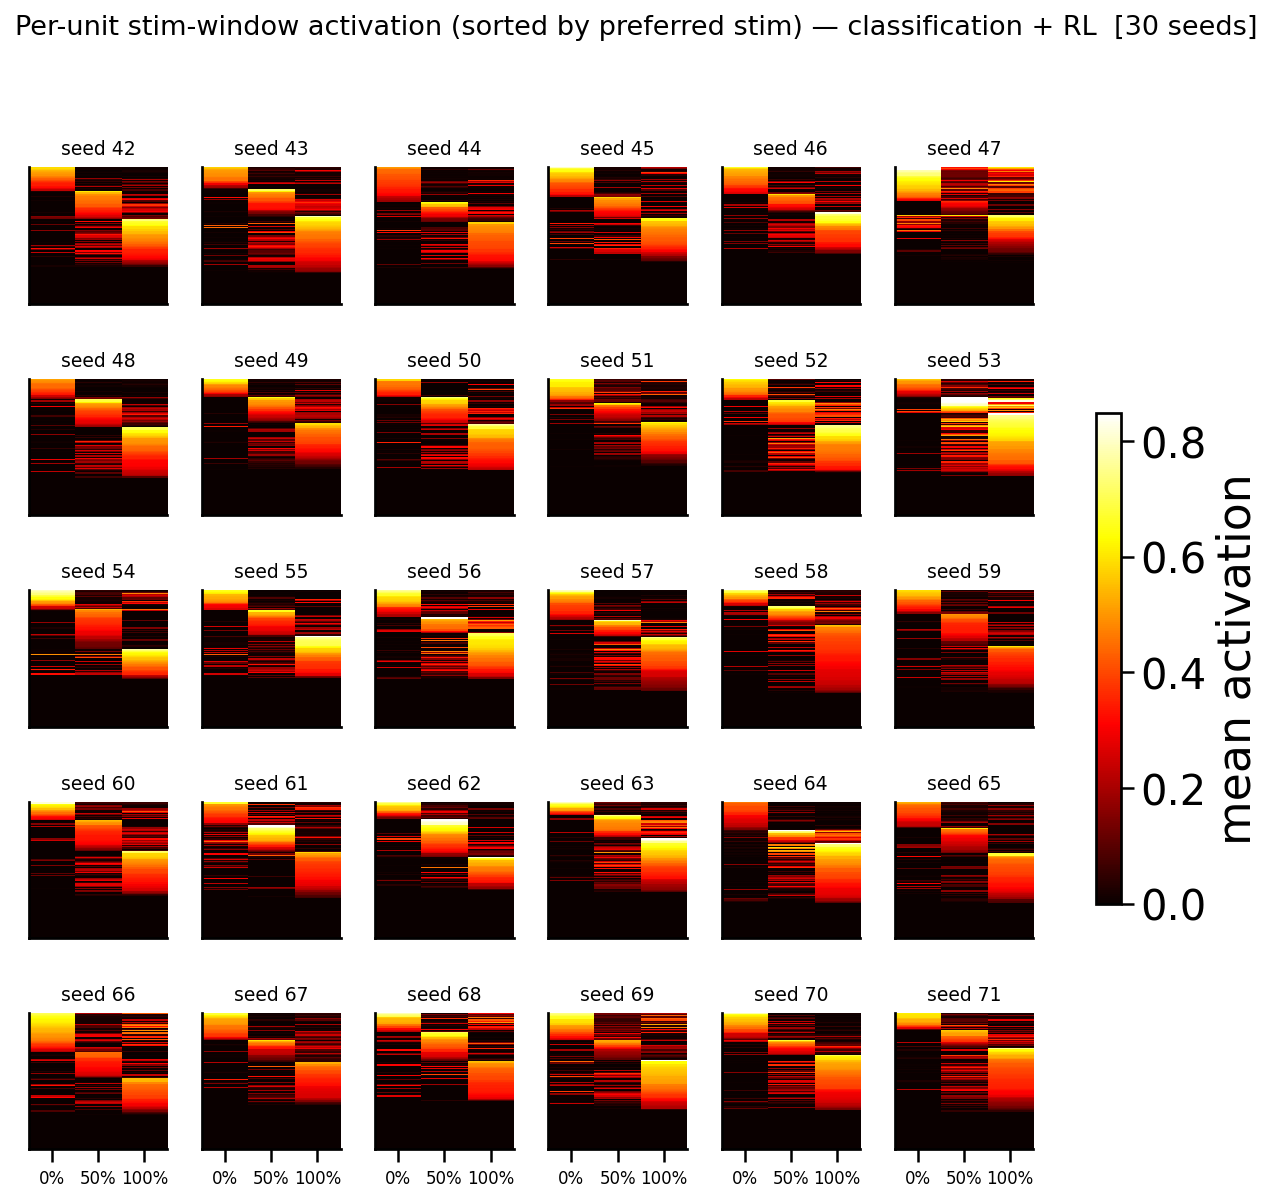

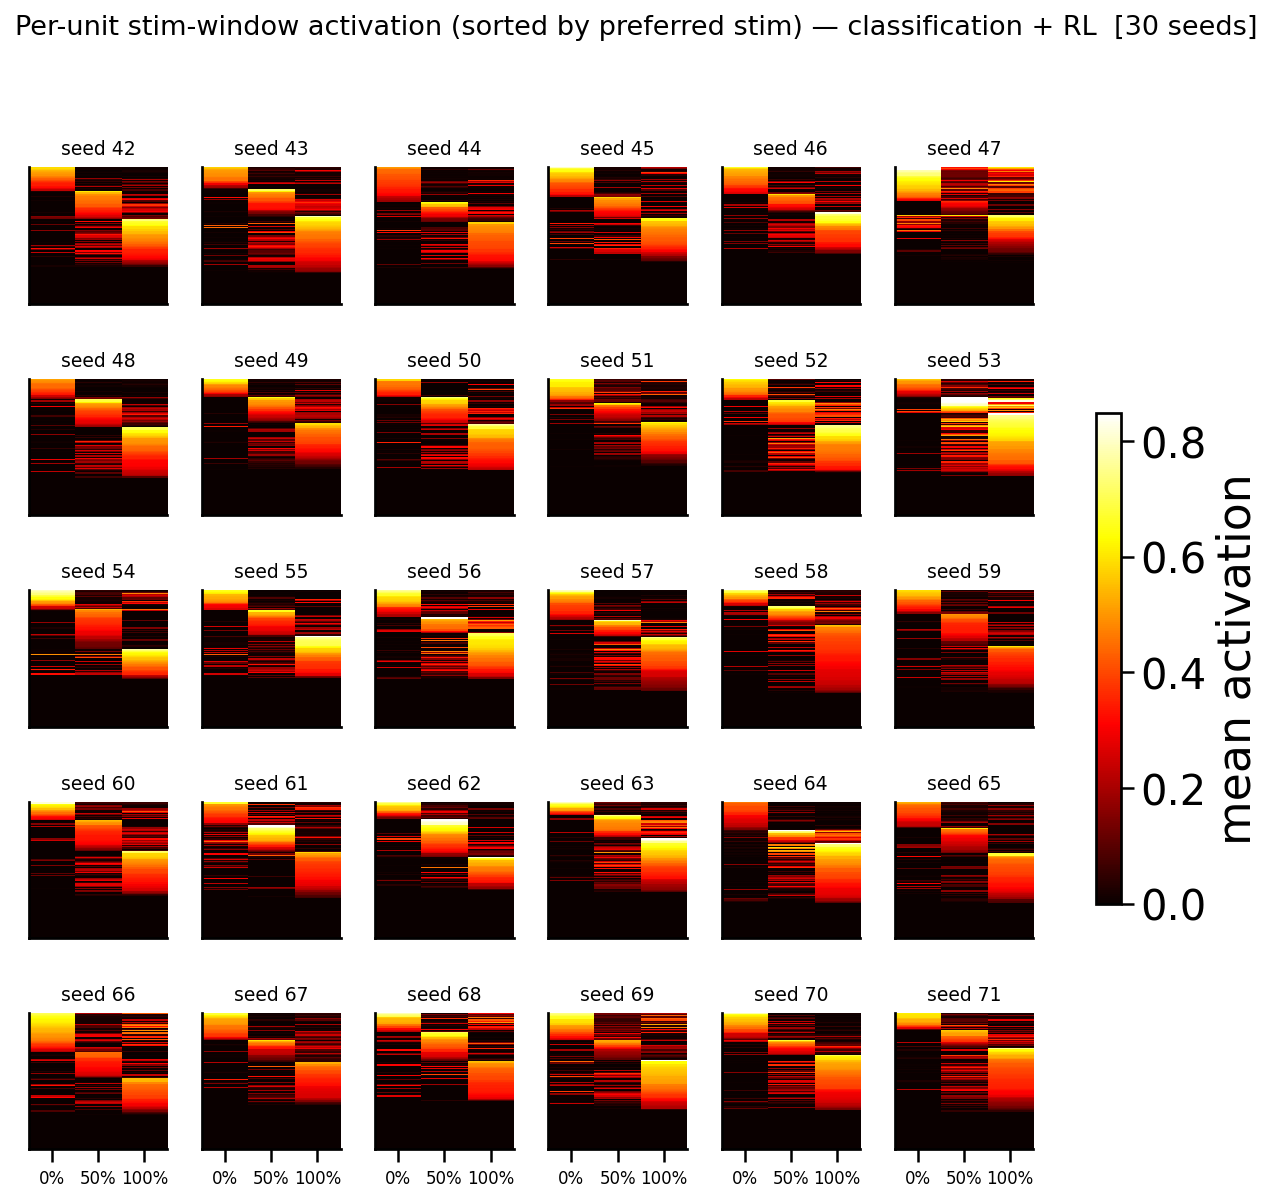

In [8]:
vmax = F.tuning_vmax(D)            # common scale across all 3 models
F.heatmap_montage(D, 'classif_rl', vmax=vmax)

## Responsiveness-group trial-aligned grid (one model)
`show_counts=True` (default) prints each group's neuron count + % in the panel titles. By default the grids share **one y-axis across all models** (scaled to the highest-magnitude model) so they're comparable — pass `ylim=F.group_grid_ylim(D)`; omit `ylim` to self-scale this model.

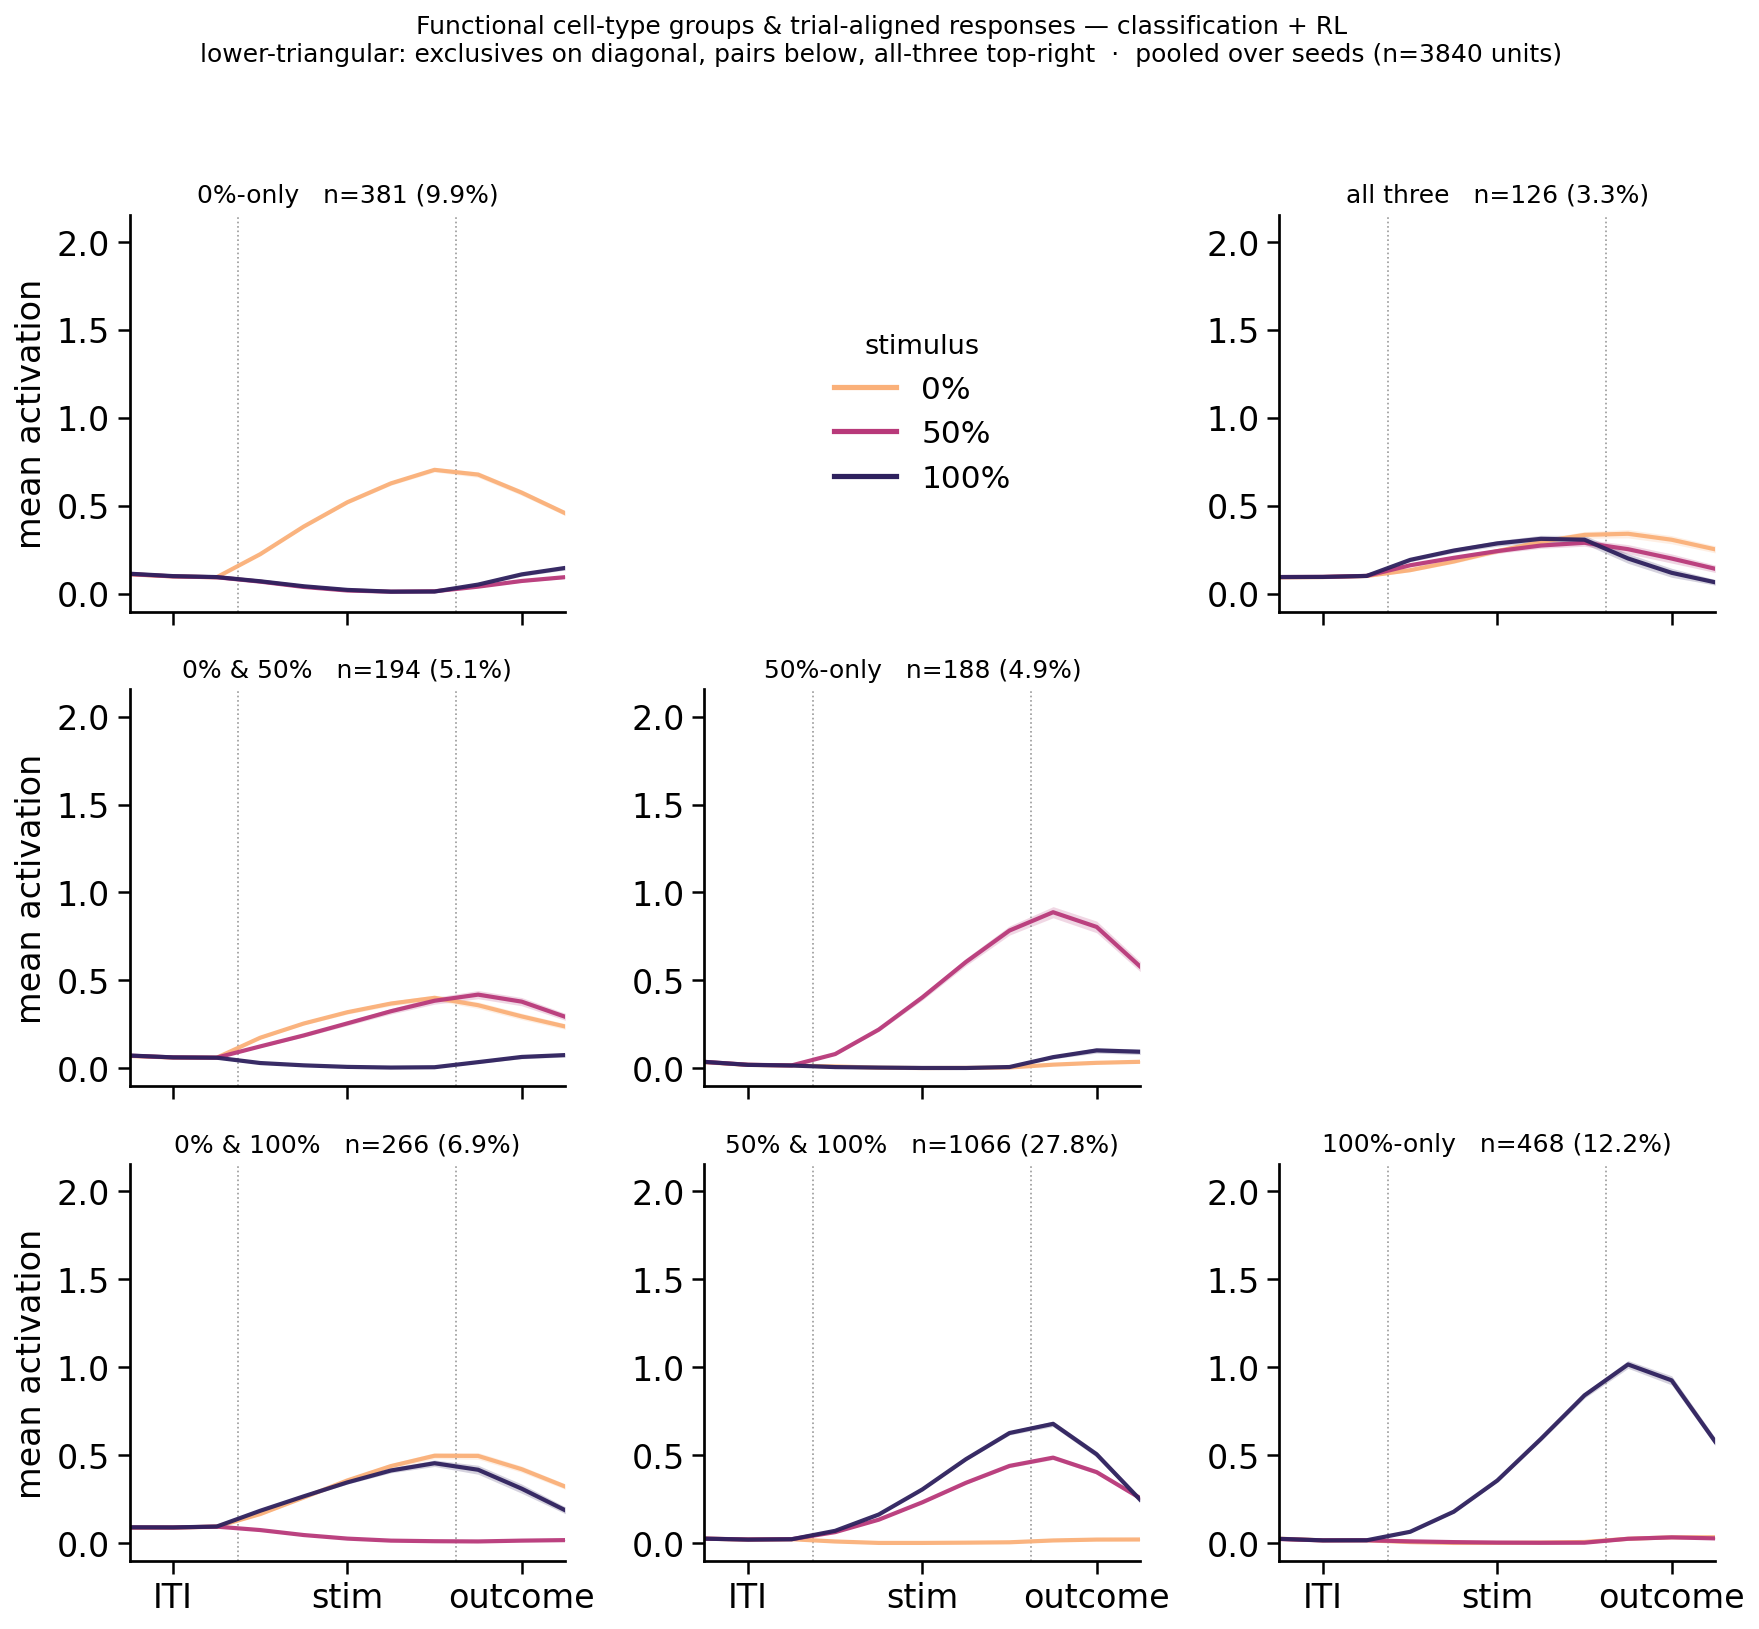

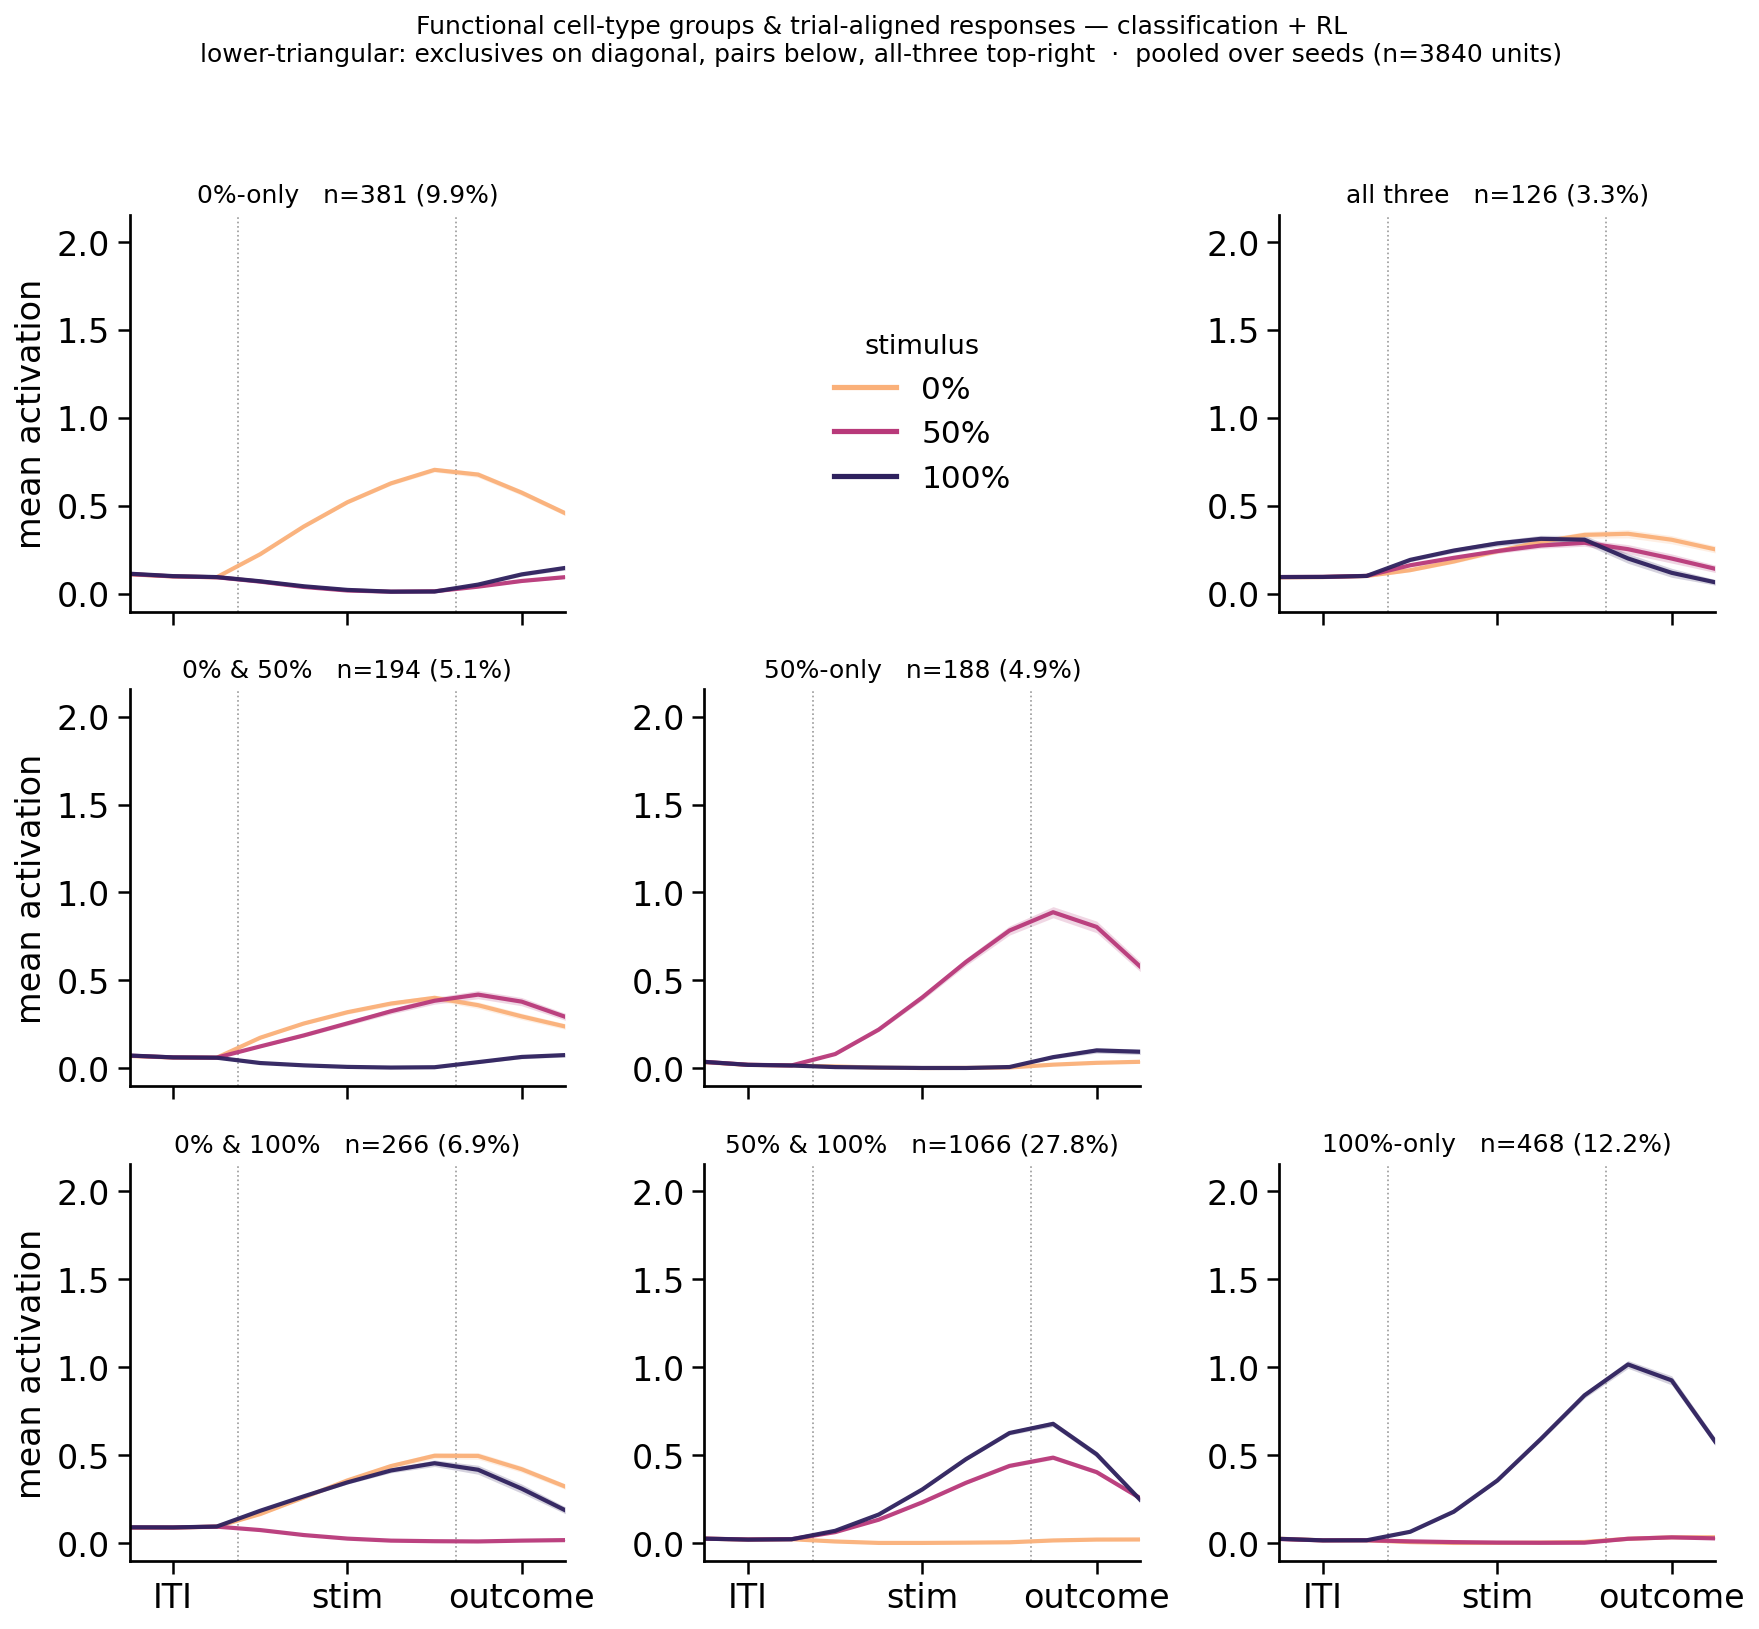

In [9]:
F.group_grid(D, 'classif_rl', show_counts=True, ylim=F.group_grid_ylim(D))

## Save every figure to `figures/` (PNG + PDF)
`annotate=True` adds the bar count/%, `show_counts=False` hides the group-grid counts.

In [10]:
F.make_all(D, OUT, annotate=False, show_counts=True)
print('saved ->', OUT)

  -> responsive_per_stim.png / .pdf
  -> responsive_per_stim_classif_rl.png / .pdf
  -> responsive_per_stim_rl_only.png / .pdf
  -> responsive_per_stim_classif_rl_readout_only.png / .pdf


  -> population_activity_per_stim.png / .pdf
  -> population_activity_per_stim_classif_rl.png / .pdf
  -> population_activity_per_stim_rl_only.png / .pdf
  -> population_activity_per_stim_classif_rl_readout_only.png / .pdf


  -> vigour_per_stim.png / .pdf
  -> vigour_per_stim_classif_rl.png / .pdf
  -> vigour_per_stim_rl_only.png / .pdf


  -> vigour_per_stim_classif_rl_readout_only.png / .pdf
  -> responder_groups.png / .pdf


  -> activation_heatmaps_classif_rl.png / .pdf


  -> celltype_group_grid_classif_rl.png / .pdf
  -> heatmap_classif_rl_seed42.png / .pdf


  -> activation_heatmaps_rl_only.png / .pdf


  -> celltype_group_grid_rl_only.png / .pdf
  -> heatmap_rl_only_seed42.png / .pdf


  -> activation_heatmaps_classif_rl_readout_only.png / .pdf


  -> celltype_group_grid_classif_rl_readout_only.png / .pdf
  -> heatmap_classif_rl_readout_only_seed42.png / .pdf
saved -> /tmp/nbexec/figures


## Appendix — responder definition: positive-only vs two-sided

All the figures above use the **positive-only (excitatory)** rule — a unit is a responder to a stimulus only if its response is significantly *above* baseline (the default everywhere). Here we recompute responsiveness straight from the raw `time_resolved/` files under a **two-sided** rule (any significant difference, including *suppressed* units) and compare the two bar plots — without the exclusivity filter (responders per stimulus) and with it (responder groups).

In [11]:
import build_figure_data_from_timeresolved as bd
TR = DATA / 'time_resolved'
D_pos, _ = bd.build_data(TR, direction='excitatory')   # positive-only (default)
D_two, _ = bd.build_data(TR, direction='two_sided')    # any significant difference
print('rebuilt under both definitions')

rebuilt under both definitions


### Responders per stimulus (no exclusivity filter)

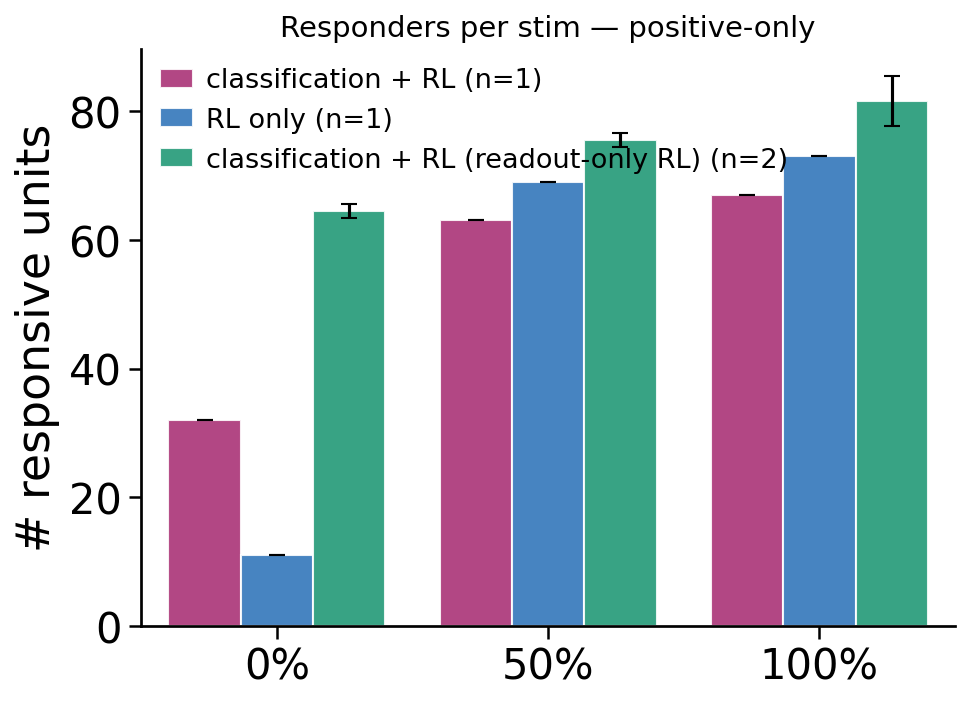

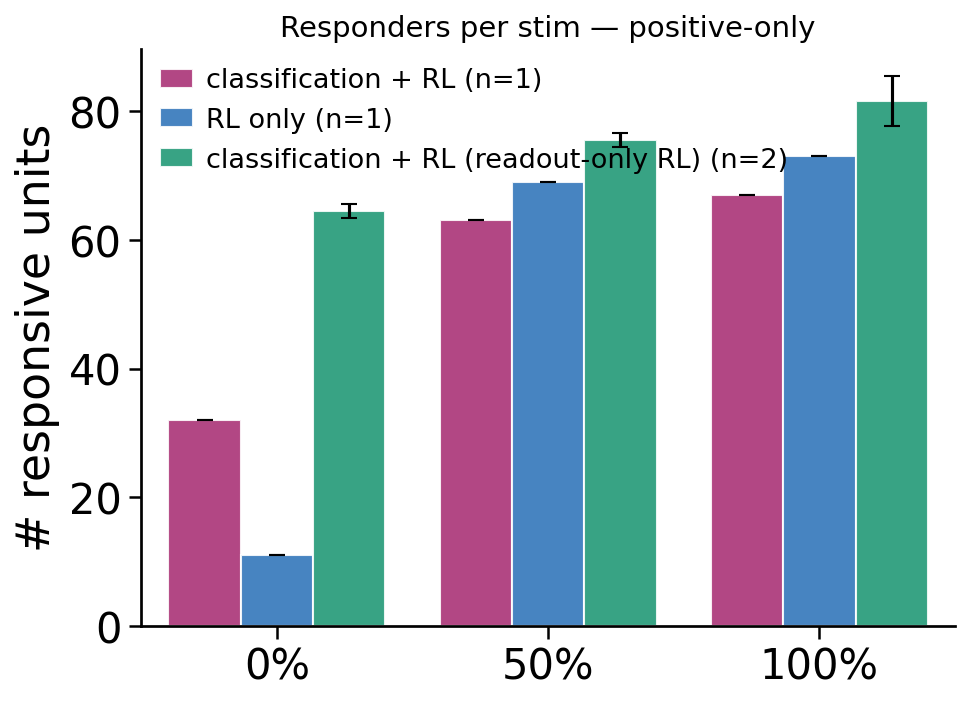

In [12]:
F.bar_metric(D_pos, 'n_responsive', ylabel='# responsive units',
             title='Responders per stim — positive-only')[0]

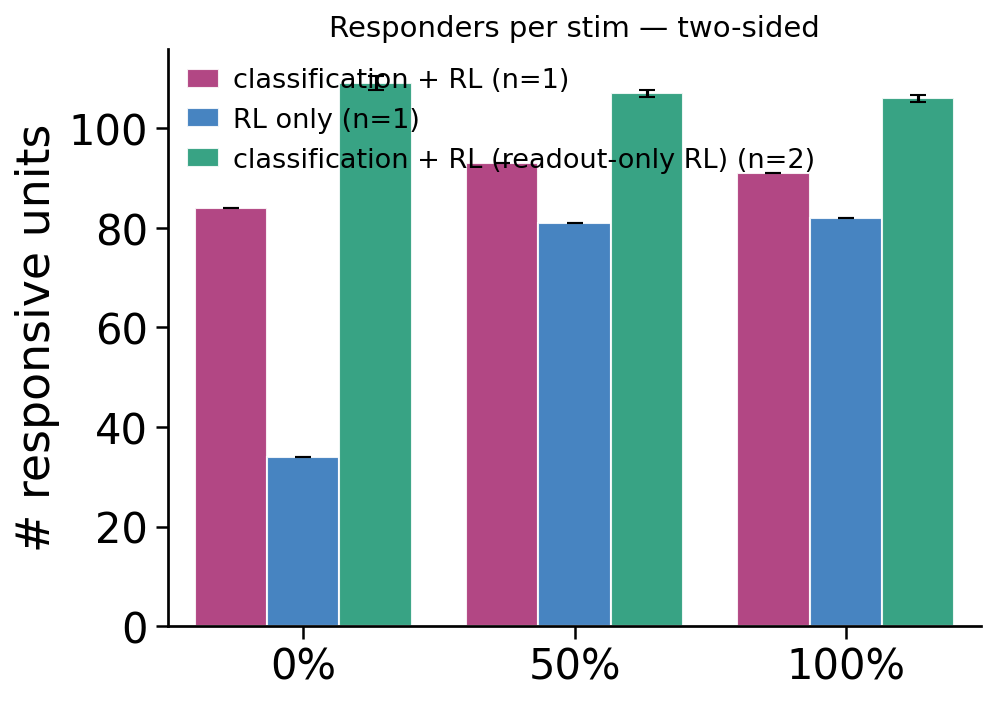

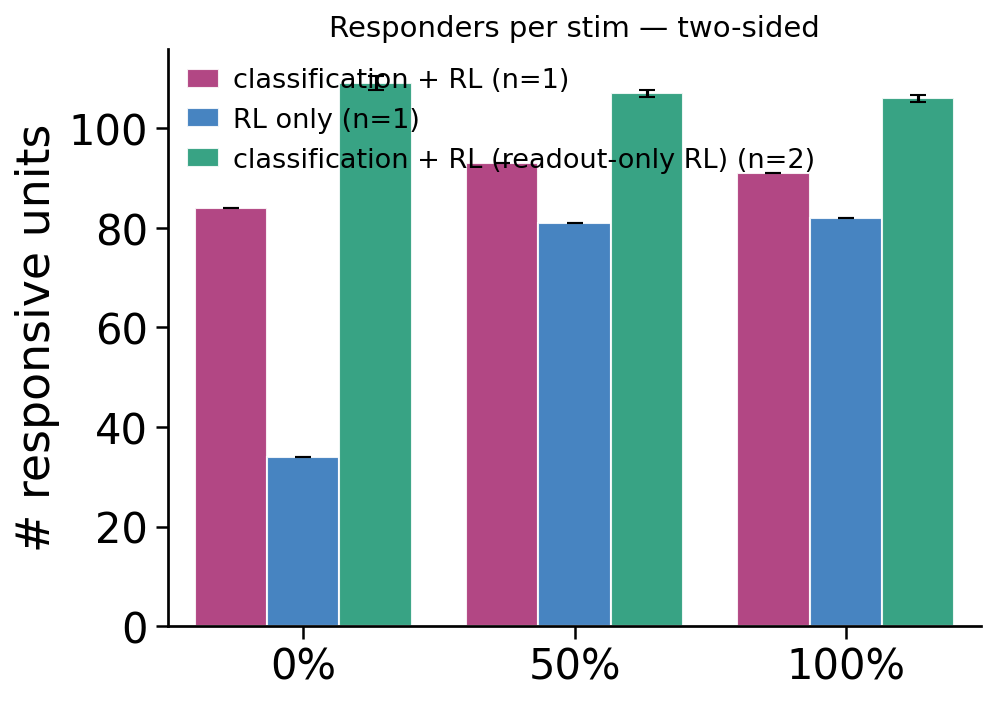

In [13]:
F.bar_metric(D_two, 'n_responsive', ylabel='# responsive units',
             title='Responders per stim — two-sided')[0]

### Responder groups (exclusivity filter + mixed groups)

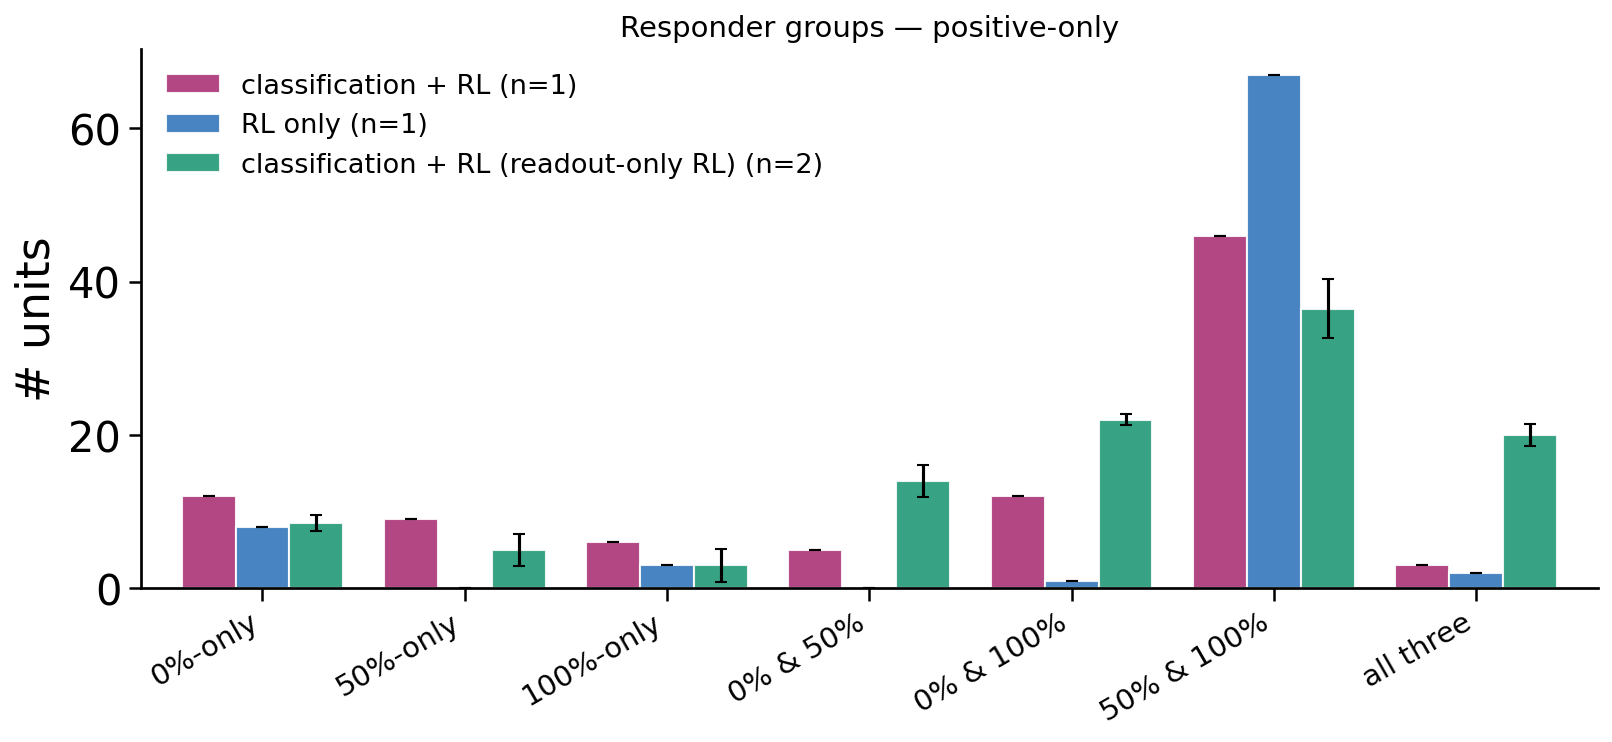

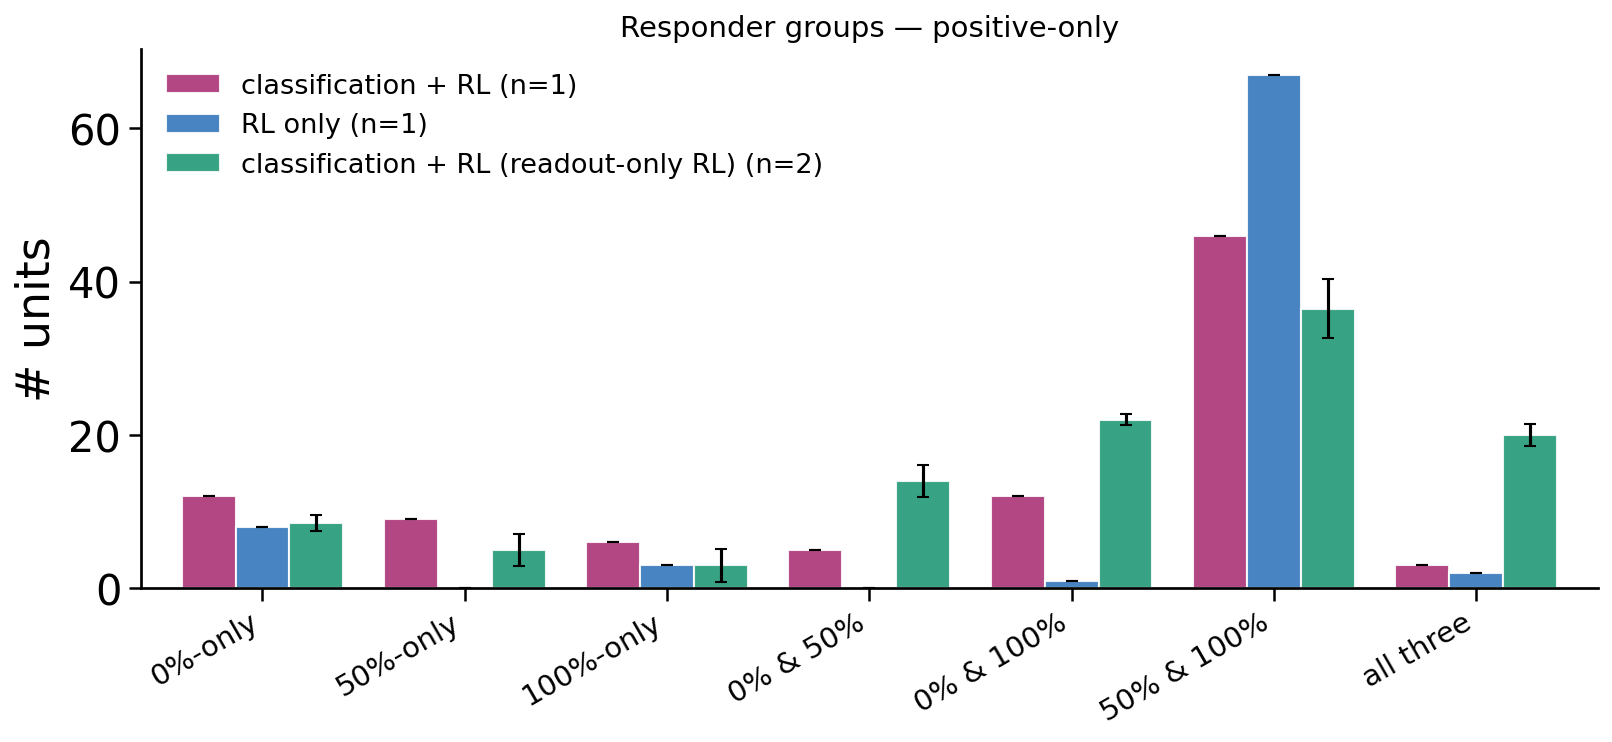

In [14]:
F.bar_responder_groups(D_pos, title='Responder groups — positive-only')[0]

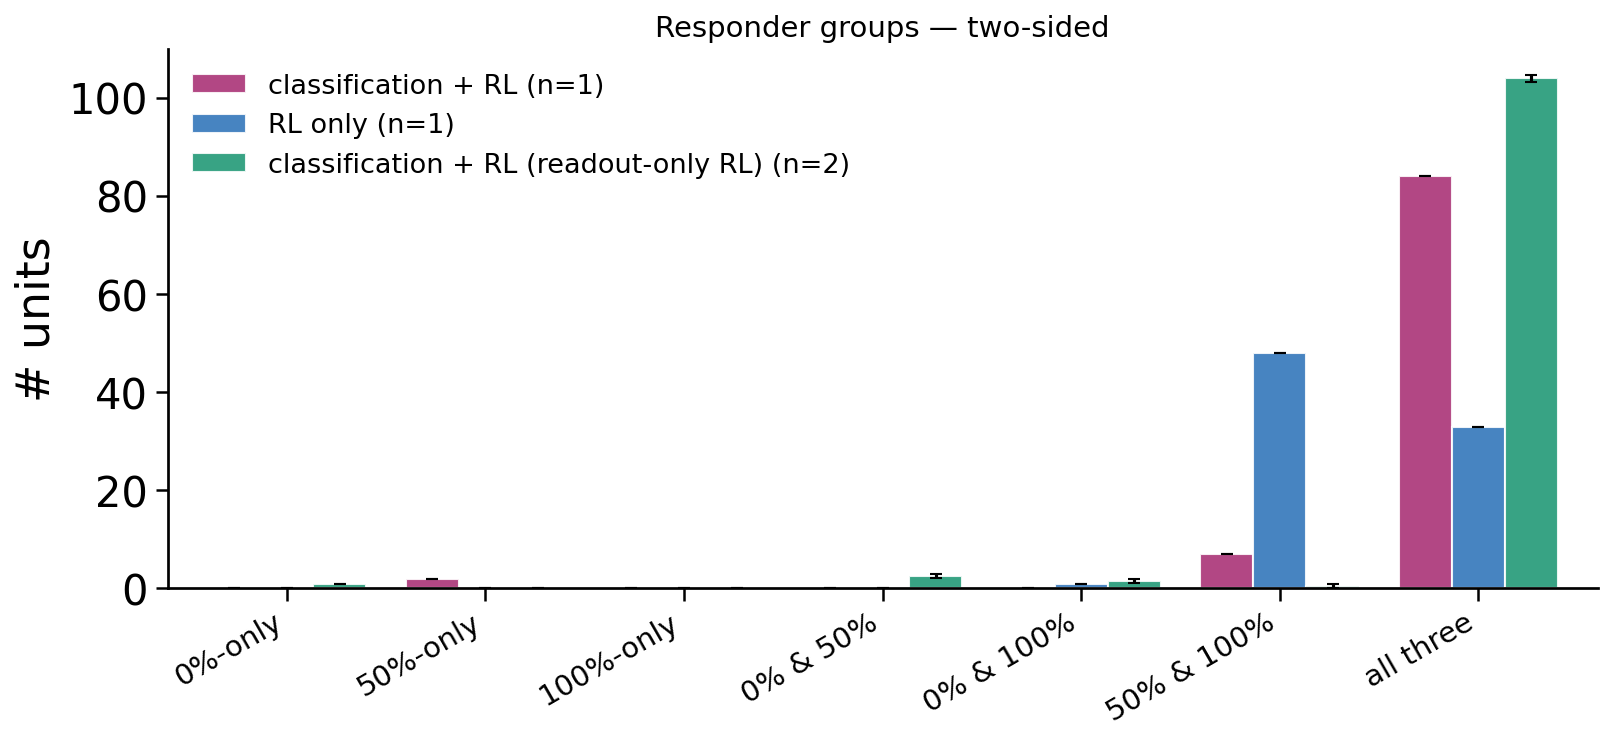

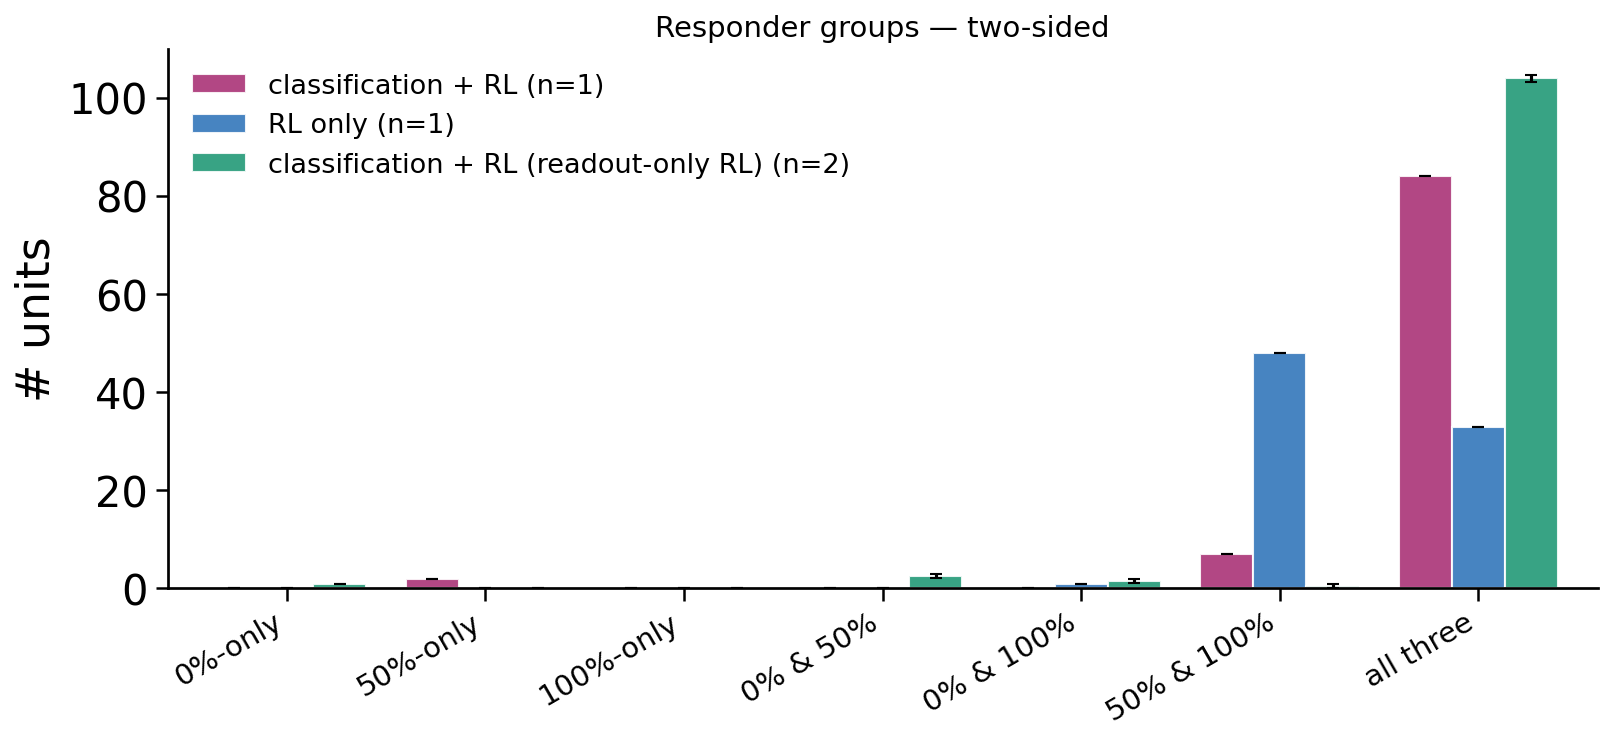

In [15]:
F.bar_responder_groups(D_two, title='Responder groups — two-sided')[0]